License

- Content (explanatory text, figures): CC BY 4.0 — see /LICENSE-CONTENT
- Code cells and standalone code files: MIT License — see /LICENSE-CODE

Attribution example: Getman, R. (2026). CBE 3610 Python Notebooks and Course Materials. https://github.com/dr-rachel-bg-teaching/CBE3610


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

## Given data

In [ ]:
CP = np.array([0.010, 0.012, 0.014, 0.016, 0.012])      # [CPA, CPB, CPC, CPD, CPI], kcal/mol/K
Hrxn = np.array([-15 * 2, -10 * (2/3)])                 # [H1A, H2C] kcal/mol B, kcal/mol A
nu = np.array([[-1, -2, 1, 0], [-2/3, 0, -1, 1/3]])

# Kinetic parameters: (k0, T0, E) for reaction 1 and 2
# rate constants: rxn 1: basis = A, units = L^2/mol^2/min. rxn 2: basis = C, units = L^4/mol^4/min.
# T0 and E are in units of K and kcal/mol, respectively.
kinetics = ((40, 300, 8), (2, 300, 12))
R_gas = 0.001986 # kcal/mol/K

# Reactor & Feed Specifications
V_max = 10 # L, can be increased (max is for the integrator)

Fcool, CPcool, Ta0 = 50, 0.010, 325 # mol/min, kcal/mol/K, K
Ua = 0.080 # kcal/L/min/K
CT0, FA0, T0 = 0.2, 5, 300 # mol/L, mol/min, K
thetaI = 0 # inert
FI0 = FA0 * thetaI
thetaB = 2
initial_conditions = [FA0, FA0*thetaB, 0, 0, T0, Ta0] # A, B, C, D, T, Ta

## PFR design equations

In [ ]:
def PFR(pfrvol, y, nu, Hrxn, CP, kinetics, R_gas, FI0, Fcool, CPcool, Ua, CT0, T0):
    F = y[:4]  # [FA, FB, FC, FD]
    T, Ta = y[4], y[5]

    # total molar flowrate
    Ftot = np.sum(F) + FI0

    # concentration equations
    C = CT0 * (F / Ftot) * (T0 / T)

    # Arrhenius equations
    k1 = kinetics[0][0] * np.exp((kinetics[0][2] / R_gas) * (1 / kinetics[0][1] - 1 / T))
    k2 = kinetics[1][0] * np.exp((kinetics[1][2] / R_gas) * (1 / kinetics[1][1] - 1 / T))

    # reaction rates
    r = np.array([k1 * C[0] * C[1]**2, k2 * C[0]**2 * C[2]**3])

    # species rates
    rnet = np.dot(nu.T, r)

    # Energy Balance Terms
    Qg = np.sum(-Hrxn * r)
    Qr = Ua * (Ta - T)
    sumFCP = np.dot(np.append(F, FI0), CP)

    # energy balances on the
    dTdV = (Qg + Qr) / sumFCP
    dTadv = -Qr / (Fcool * CPcool)

    # coupled odes
    return np.append(rnet, [dTdV, dTadv])

## Solve

In [ ]:
V_eval = np.linspace(0, V_max, 400)
sol = solve_ivp(PFR, t_span=(0, V_max), y0=initial_conditions, t_eval=V_eval, args=(nu, Hrxn, CP, kinetics, R_gas, FI0, Fcool, CPcool, Ua, CT0, T0))

## Extract data

In [ ]:
F_profile = sol.y[:4, :]
T_profile, Ta_profile = sol.y[4, :], sol.y[5, :]

# decision criteria
print("Selectivity (S_C/D) = ",F_profile[2, -1]/F_profile[3, -1])
print("Conversion = ",(FA0 - F_profile[0, -1]) / FA0)
print("Maximum temperature = ",np.max(T_profile)," K")

Selectivity (S_C/D) =  1236.5096790106543
Conversion =  0.9222368401278833
Maximum temperature =  887.5963777989595  K


## Plot

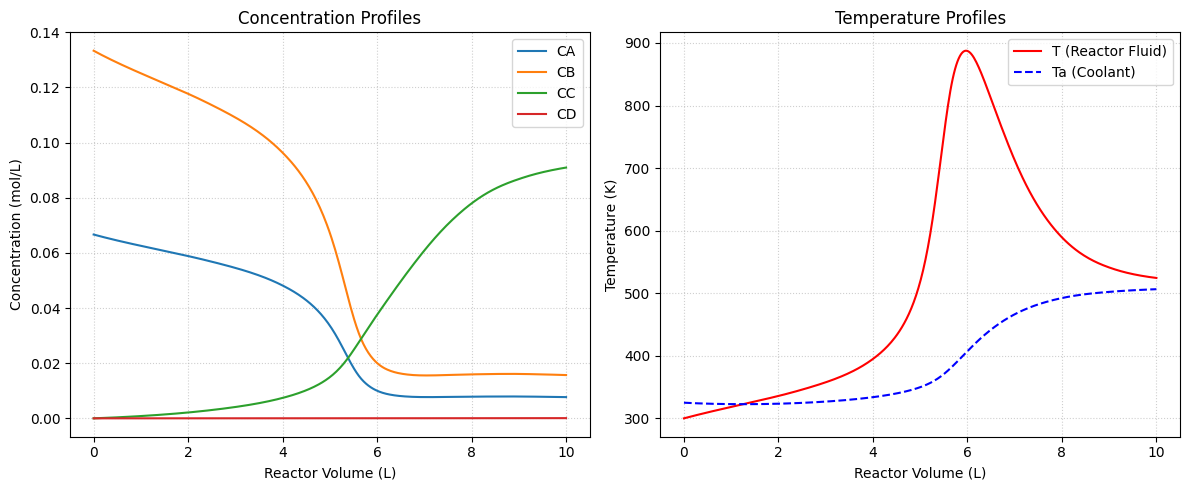

In [ ]:
# concentrations
Ftot_profile = np.sum(F_profile, axis=0)
C_profile = CT0 * (F_profile / Ftot_profile) * (T0 / T_profile)

plt.figure(figsize=(12, 5))

# Plot 1: Concentrations
plt.subplot(1, 2, 1)
for i, label in enumerate(["CA", "CB", "CC", "CD"]):
    plt.plot(sol.t, C_profile[i], label=label)
plt.xlabel("Reactor Volume (L)")
plt.ylabel("Concentration (mol/L)")
plt.title("Concentration Profiles")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

# Plot 2: Temperatures
plt.subplot(1, 2, 2)
plt.plot(sol.t, T_profile, 'r-', label="T (Reactor Fluid)")
plt.plot(sol.t, Ta_profile, 'b--', label="Ta (Coolant)")
plt.xlabel("Reactor Volume (L)")
plt.ylabel("Temperature (K)")
plt.title("Temperature Profiles")
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend()

plt.tight_layout()
plt.show()